# Bayesian Optimisation of Optogenetic Protrusion Stimulation (Simulated)

This notebook uses a **simulated microscope** with `ProtrusionCell` to find
the optimal optogenetic stimulation parameters that maximise cell protrusions
(measured as area increase).

**Two steerable parameters (BO optimises these):**
- `stim_angle` – angular position of a fixed-size stimulation patch around the cell circumference (0 = major-axis tip, 0.5 = opposite tip)
- `stim_radial` – radial position of the patch from cell centre (0) to cell edge (1)

**One non-steerable covariate:**
- `opto_rtk_expression` – random per-cell receptor expression level (higher → more response)

**Objective:** maximise `area_change` (fractional area increase after 10 stimulation frames)

The experiment runs through the **full MDA pipeline**: SimulatedMicroscope → segmentation → feature extraction → tracking.

In [ ]:
import os
import time
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suppress JAX/XLA debug messages – env vars must be set before first jax import
os.environ["JAX_LOG_COMPILES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gpax
import jax

# Silence all jax internal loggers (created lazily, so we catch them after import)
jax.config.update("jax_log_compiles", False)
for _name in list(logging.Logger.manager.loggerDict):
    if "jax" in _name or "absl" in _name:
        logging.getLogger(_name).setLevel(logging.WARNING)

from rtm_pymmcore.data_structures import (
    Channel,
    StimTreatment,
    SegmentationMethod,
    Fov,
)
import rtm_pymmcore.utils as utils
from rtm_pymmcore.agents.bo_optimization_gpax import (
    BOptGPAX,
    BO_Parameter,
    BO_Objective,
    BO_Covariate,
    compute_protrusion_ground_truth,
)
from rtm_pymmcore.microscope.SimulatedMicroscope import SimulatedMicroscope
from rtm_pymmcore.microscope_simulation.cell_protrusion import ProtrusionCell
from rtm_pymmcore.stimulation.two_axis_percentage_of_cell import StimTwoAxisPercentage
from rtm_pymmcore.segmentation.base_segmentation import SegmentatorBinary
from rtm_pymmcore.feature_extraction.simple_fe import SimpleFE
from rtm_pymmcore.tracking.trackpy import TrackerTrackpy
from rtm_pymmcore.img_processing_pip import ImageProcessingPipeline
from scipy.spatial import cKDTree

## Experimental settings

In [ ]:
# ---------------------------------------------------------------------------
# Simulated microscope with ProtrusionCells
# ---------------------------------------------------------------------------
mic = SimulatedMicroscope(
    nb_cells=60,
    cell_type="protrusion",
    viewport_width=512,
    viewport_height=512,
    rng_seed=42,
    brownian_d=0.0,
    channel_rendering_modes={0: 1},  # single channel: nucleus fluorescence
    time_scale=5.0,  # speed up physics so protrusions develop faster
)
mic.mmc.setChannelGroup("Channel")

# ---------------------------------------------------------------------------
# Experiment timing
# ---------------------------------------------------------------------------
FIRST_FRAME_STIMULATION = 2
N_FRAMES = 12  # 2 baseline + 10 stimulation frames
TIME_BETWEEN_TIMESTEPS = 2  # seconds (wall-clock wait between frames)
TIME_PER_FOV = 1  # irrelevant for simulation, needed for real microscopes

# ---------------------------------------------------------------------------
# Storage
# ---------------------------------------------------------------------------
base_path = os.path.join(os.getcwd(), "simulation_output")
experiment_name = "sim_bo_protrusion"
path = os.path.join(base_path, experiment_name)

# ---------------------------------------------------------------------------
# Channels
# ---------------------------------------------------------------------------
channels = [Channel(name="Nucleus", exposure=300)]
condition = ["optoRTK"]

# ---------------------------------------------------------------------------
# Stimulation treatment template (applied at frames 2-11)
# ---------------------------------------------------------------------------
stim_treatment = [
    StimTreatment(
        treatment_name="Protrusion Stim",
        stim_timestep=tuple(range(FIRST_FRAME_STIMULATION, N_FRAMES)),
        stim_exposure_list=(100,) * (N_FRAMES - FIRST_FRAME_STIMULATION),
        stim_power=10,
        stim_channel_name="Stim",
        stim_channel_group="Channel",
        stim_channel_device_name="Spectra",
        stim_channel_power_property_name="Cyan_Level",
    )
]

utils.print_stim_exposures_timesteps(stim_treatment)

# ---------------------------------------------------------------------------
# Image processing pipeline (created once, reused across BO iterations)
# ---------------------------------------------------------------------------
pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=[
        SegmentationMethod(
            name="labels",
            segmentation_class=SegmentatorBinary(),
            use_channel=0,
            save_tracked=True,
        )
    ],
    feature_extractor=SimpleFE("labels"),
    tracker=TrackerTrackpy(search_range=50),
    stimulator=StimTwoAxisPercentage(),
)
mic.set_pipeline(pipeline=pipeline)

Pattern Name:  Protrusion Stim
100 at 2
100 at 3
100 at 4
100 at 5
100 at 6
100 at 7
100 at 8
100 at 9
100 at 10
100 at 11

Directory c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\simulation_output\sim_bo_protrusion\raw already exists
Directory c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\simulation_output\sim_bo_protrusion\tracks already exists
Directory c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\simulation_output\sim_bo_protrusion\stim_mask already exists
Directory c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\simulation_output\sim_bo_protrusion\stim already exists
Directory c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\simulation_output\sim_bo_protrusion\particles already exists
Directory c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\simulation_output\sim_bo_protrusion\labels already exists


## BO Agent subclass

Implements the two abstract methods of `BOptGPAX`:
- `_create_df_acquire_for_exp_cycle` – builds the full acquisition dataframe for one BO iteration
- `_run_experiment_and_preprocess_results` – resets the simulation, runs the MDA pipeline, reads tracks, computes area change, and matches opto-RTK expression from the simulation cells

In [ ]:
class ProtrusionBOptGPAX(BOptGPAX):
    """BO agent that runs protrusion experiments on a SimulatedMicroscope.

    Each BO iteration is a separate *phase* (like the multi-phase
    approach in ``01_full_FOV_stimulation_ERK_new_API.ipynb``).  The
    same ``Fov`` object is reused so that cell tracking is continuous
    across iterations.
    """

    def __init__(
        self,
        microscope: SimulatedMicroscope,
        storage_path: str,
        channels: list,
        condition: list,
        stim_treatment: list,
        n_frames: int = 12,
        first_frame_stim: int = 2,
        time_between_timesteps: float = 2,
        time_per_fov: float = 1,
        **kwargs,
    ):
        super().__init__(microscope=microscope, **kwargs)
        self.storage_path = storage_path
        self.channels = channels
        self.condition = condition
        self.stim_treatment = stim_treatment
        self.n_frames = n_frames
        self.first_frame_stim = first_frame_stim
        self.time_between_timesteps = time_between_timesteps
        self.time_per_fov = time_per_fov
        self._phase_counter = 0

        # --- Single FOV, reused for continuous tracking ---
        sim = self.microscope.simulator
        cx = (sim.width - sim.viewport_width) / 2
        cy = (sim.height - sim.viewport_height) / 2
        self._fov = Fov(0)
        self._fov.x = cx
        self._fov.y = cy
        self._fov.z = None
        self._fov.name = "centre"

        # --- Let physics settle and record cell data once ---
        for _ in range(30):
            sim.update(dt=0.05)
        self._df_sim_cells = pd.DataFrame(
            [
                {
                    "cx": c.center[0],
                    "cy": c.center[1],
                    "opto_rtk_expression": c.opto_rtk_expression,
                }
                for c in sim._cells
                if isinstance(c, ProtrusionCell)
            ]
        )

    # ------------------------------------------------------------------

    def _get_ground_truth_grid(self, unique_x1, unique_x2, cov_mean):
        """Approximate ground truth from circular-cell simulation model."""
        return compute_protrusion_ground_truth(
            unique_x1,
            unique_x2,
            cov_mean,
            n_stim_frames=self.n_frames - self.first_frame_stim,
        )

    # ------------------------------------------------------------------

    def _create_df_acquire_for_exp_cycle(self, parameters: dict) -> pd.DataFrame:
        """Build a full df_acquire for one BO iteration (= one phase)."""
        phase_id = self._phase_counter

        df_acquire = utils.generate_df_acquire(
            fovs=[self._fov],
            n_frames=self.n_frames,
            time_between_timesteps=self.time_between_timesteps,
            time_per_fov=self.time_per_fov,
            channels=self.channels,
            phase_name=f"BO_iter_{phase_id}",
            phase_id=phase_id,
            condition=self.condition,
        )

        df_acquire = utils.apply_stim_treatments_to_df_acquire(
            df_acquire,
            self.stim_treatment,
            self.condition,
        )

        # Inject the BO parameters so the stimulator can read them
        df_acquire["stim_angle"] = parameters["stim_angle"]
        df_acquire["stim_radial"] = parameters["stim_radial"]

        return df_acquire

    # ------------------------------------------------------------------

    def _run_experiment_and_preprocess_results(
        self, df_acquire: pd.DataFrame
    ) -> pd.DataFrame:
        """Run one phase of the MDA pipeline and compute area change."""
        phase_id = self._phase_counter
        self._phase_counter += 1

        mic = self.microscope

        # --- Run the experiment (one phase) ---
        mic.run_experiment(df_acquire)

        # --- Read tracks for this specific phase ---
        track_file = os.path.join(
            self.storage_path,
            "tracks",
            f"0_phase_{phase_id}_latest.parquet",
        )
        try:
            df_tracks = pd.read_parquet(track_file)
        except Exception as e:
            print(f"Warning: could not read tracks for phase {phase_id}: {e}")
            return pd.DataFrame()

        if df_tracks.empty or "particle" not in df_tracks.columns:
            print(f"Warning: no tracked cells in phase {phase_id}.")
            return pd.DataFrame()

        # --- Compute area change per tracked cell within this phase ---
        stim_angle = float(df_acquire["stim_angle"].iloc[0])
        stim_radial = float(df_acquire["stim_radial"].iloc[0])

        results = []
        for particle_id, grp in df_tracks.groupby("particle"):
            grp_sorted = grp.sort_values("timestep")
            if len(grp_sorted) < 3:
                continue

            baseline = grp_sorted[grp_sorted["timestep"] < self.first_frame_stim]
            if baseline.empty:
                baseline_area = grp_sorted["area"].iloc[0]
            else:
                baseline_area = baseline["area"].mean()

            if baseline_area <= 0:
                continue

            final_area = grp_sorted["area"].iloc[-2:].mean()
            area_change = (final_area - baseline_area) / baseline_area

            cell_x = grp_sorted["y"].iloc[0]
            cell_y = grp_sorted["x"].iloc[0]

            results.append(
                {
                    "particle": particle_id,
                    "area_change": area_change,
                    "cell_x_viewport": cell_x,
                    "cell_y_viewport": cell_y,
                }
            )

        if not results:
            print(f"Warning: no valid area measurements in phase {phase_id}.")
            return pd.DataFrame()

        df_results = pd.DataFrame(results)

        # --- Match tracked cells to sim cells for opto_rtk_expression ---
        fov_x = float(df_acquire["fov_x"].iloc[0])
        fov_y = float(df_acquire["fov_y"].iloc[0])
        df_sim = self._df_sim_cells.copy()
        df_sim["vp_x"] = df_sim["cy"] - fov_y
        df_sim["vp_y"] = df_sim["cx"] - fov_x

        sim = mic.simulator
        vw, vh = sim.viewport_width, sim.viewport_height
        visible = (
            (df_sim["vp_x"] >= 0)
            & (df_sim["vp_x"] < vh)
            & (df_sim["vp_y"] >= 0)
            & (df_sim["vp_y"] < vw)
        )
        df_sim_visible = df_sim[visible].reset_index(drop=True)

        if df_sim_visible.empty:
            print("Warning: no simulation cells visible in viewport.")
            return pd.DataFrame()

        tree = cKDTree(df_sim_visible[["vp_x", "vp_y"]].values)
        tracked_coords = df_results[["cell_x_viewport", "cell_y_viewport"]].values
        _, indices = tree.query(tracked_coords)

        df_results["opto_rtk_expression"] = df_sim_visible.iloc[indices][
            "opto_rtk_expression"
        ].values
        df_results["stim_angle"] = stim_angle
        df_results["stim_radial"] = stim_radial

        df_out = df_results[
            [
                "stim_angle",
                "stim_radial",
                "opto_rtk_expression",
                "area_change",
            ]
        ].copy()

        print(
            f"  Phase {phase_id}: {len(df_out)} cells, "
            f"mean area_change={df_out['area_change'].mean():.4f}"
        )
        return df_out

## Configure and run Bayesian Optimisation

=== Initial sample 1/3: {'stim_angle': np.float32(0.0), 'stim_radial': np.float32(1.0)} ===
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 0: 6 cells, mean area_change=0.0000
=== Initial sample 2/3: {'stim_angle': np.float32(1.0), 'stim_radial': np.float32(0.0)} ===
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 1: 6 cells, mean area_change=0.0000
=== Initial sample 3/3: {'stim_angle': np.float32(0.0), 'stim_radial': np.float32(0.0)} ===
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 2: 6 cells, mean area_change=0.0000

=== BO Iteration 1/10 ===


sample: 100%|██████████| 1200/1200 [00:01<00:00, 1017.96it/s, 7 steps of size 5.91e-01. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      3.37      4.95      1.62      0.06      8.05    806.12      1.00
k_length[1]      3.29      4.44      1.75      0.07      8.10    664.03      1.00
k_length[2]     12.98     10.48     10.16      1.69     25.00   1088.15      1.00
    k_scale      0.11      0.11      0.07      0.00      0.24   1115.26      1.00
      noise      0.00      0.00      0.00      0.00      0.01    883.48      1.00

Computing robust acquisition over 1180 scenarios (118 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.001246, max=0.001875
  Robust acq stats: min=0.000383, max=0.020435
Computing robust acquisition over 30 scenarios (3 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.000060, max=0.000279
  Robust acq stats: min=0.000000, max=0.000000


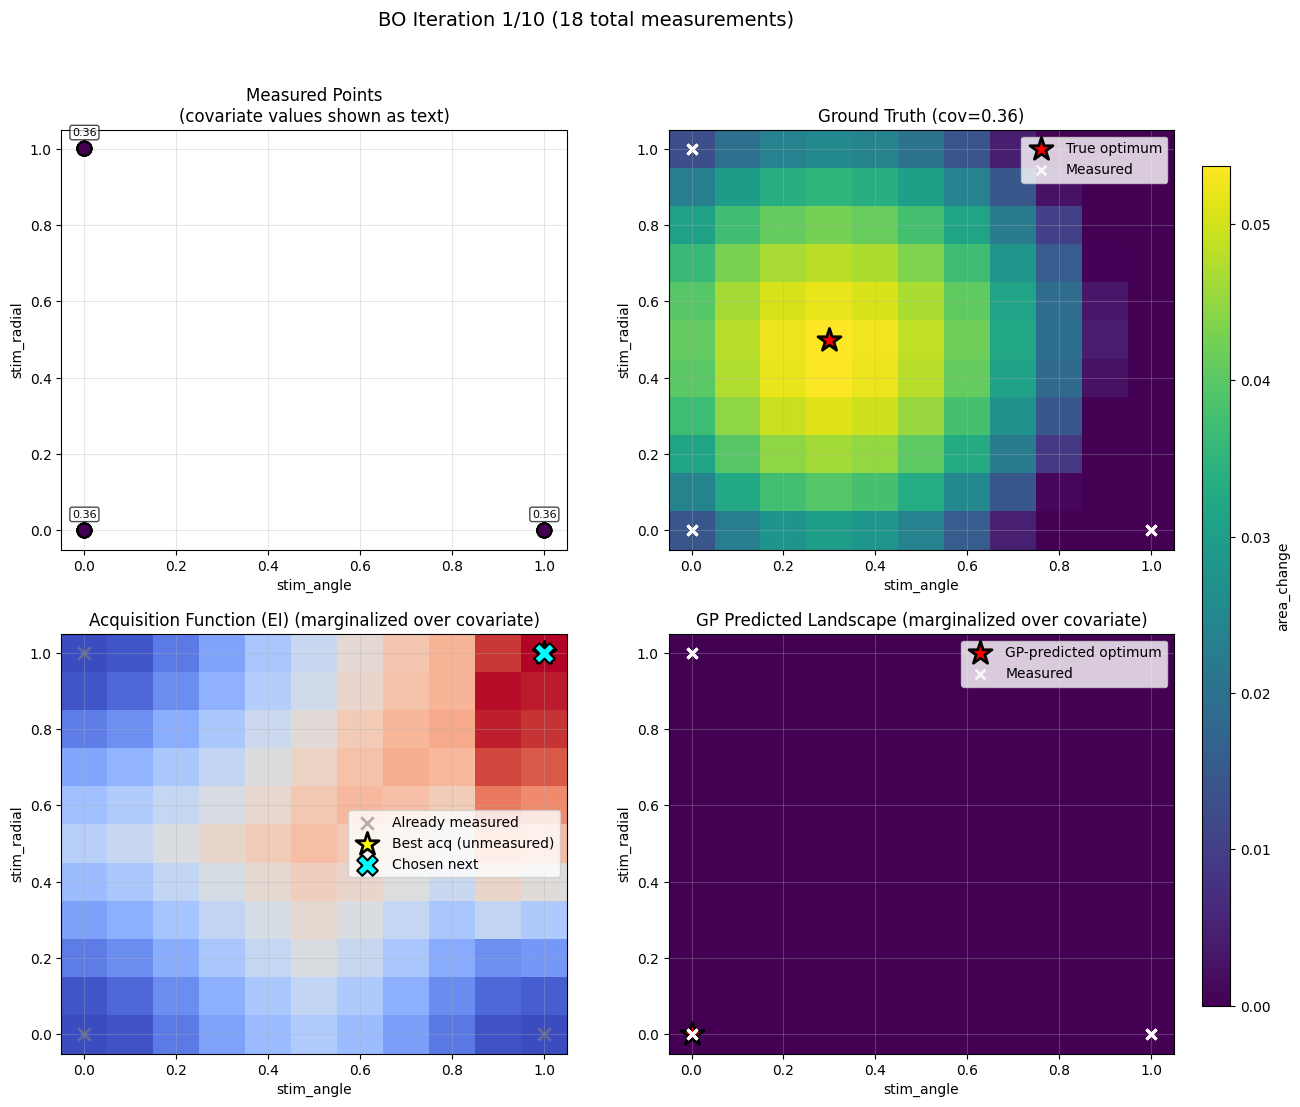

Selected parameters for next experiment: {'stim_angle': np.float64(1.0), 'stim_radial': np.float64(1.0)}
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 3: 6 cells, mean area_change=0.0319

=== BO Iteration 2/10 ===


sample: 100%|██████████| 1200/1200 [00:01<00:00, 949.83it/s, 7 steps of size 4.94e-01. acc. prob=0.81] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.05      1.18      0.75      0.09      2.16    698.86      1.00
k_length[1]      1.02      0.97      0.81      0.05      1.93    602.53      1.00
k_length[2]      1.03      1.61      0.51      0.04      2.56    520.01      1.00
    k_scale      0.65      0.38      0.57      0.11      1.18   1001.86      1.00
      noise      0.61      0.30      0.55      0.21      1.06    490.67      1.00

Computing robust acquisition over 1170 scenarios (117 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.058430, max=1.355392
  Robust acq stats: min=0.002440, max=0.036247
Computing robust acquisition over 40 scenarios (4 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.060885, max=1.575157
  Robust acq stats: min=0.000000, max=0.000000


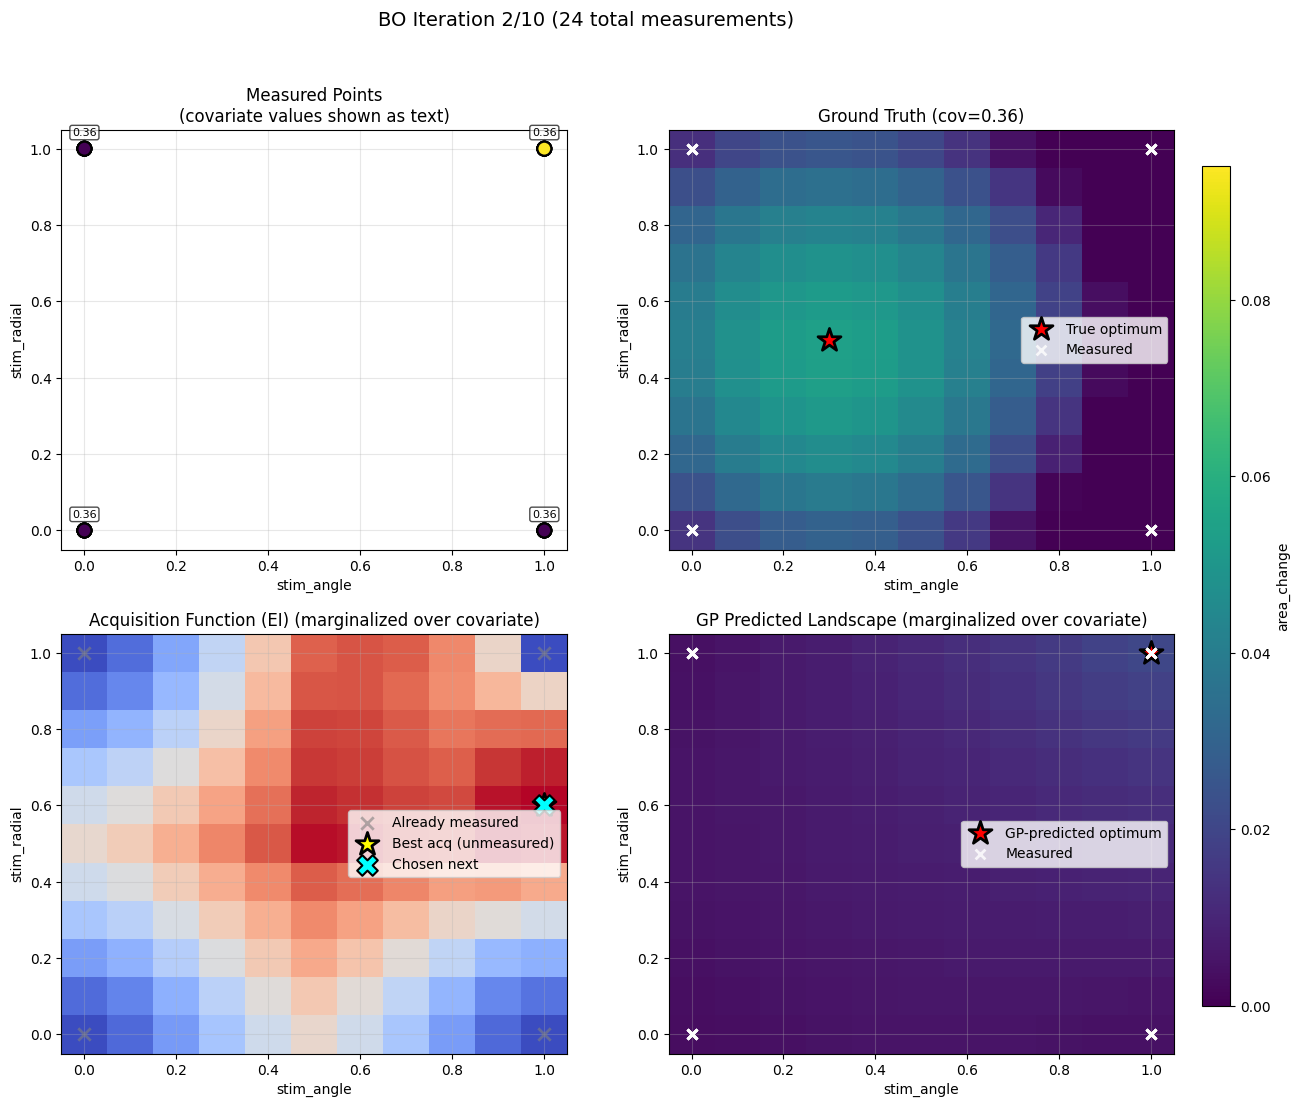

Selected parameters for next experiment: {'stim_angle': np.float64(1.0), 'stim_radial': np.float64(0.6000000000000001)}
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 4: 6 cells, mean area_change=0.0496

=== BO Iteration 3/10 ===


sample: 100%|██████████| 1200/1200 [00:01<00:00, 826.46it/s, 7 steps of size 4.90e-01. acc. prob=0.93]  



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.20      1.26      0.83      0.04      2.45    650.02      1.00
k_length[1]      1.16      1.22      0.91      0.04      1.97    435.81      1.00
k_length[2]      0.59      1.07      0.40      0.08      0.83    340.11      1.00
    k_scale      0.63      0.33      0.57      0.16      1.06   1353.05      1.00
      noise      0.50      0.22      0.45      0.21      0.85    527.63      1.00

Computing robust acquisition over 1160 scenarios (116 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=-0.172124, max=1.575645
  Robust acq stats: min=0.006861, max=0.072395
Computing robust acquisition over 50 scenarios (5 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=-0.313059, max=1.625114
  Robust acq stats: min=0.000000, max=0.000000


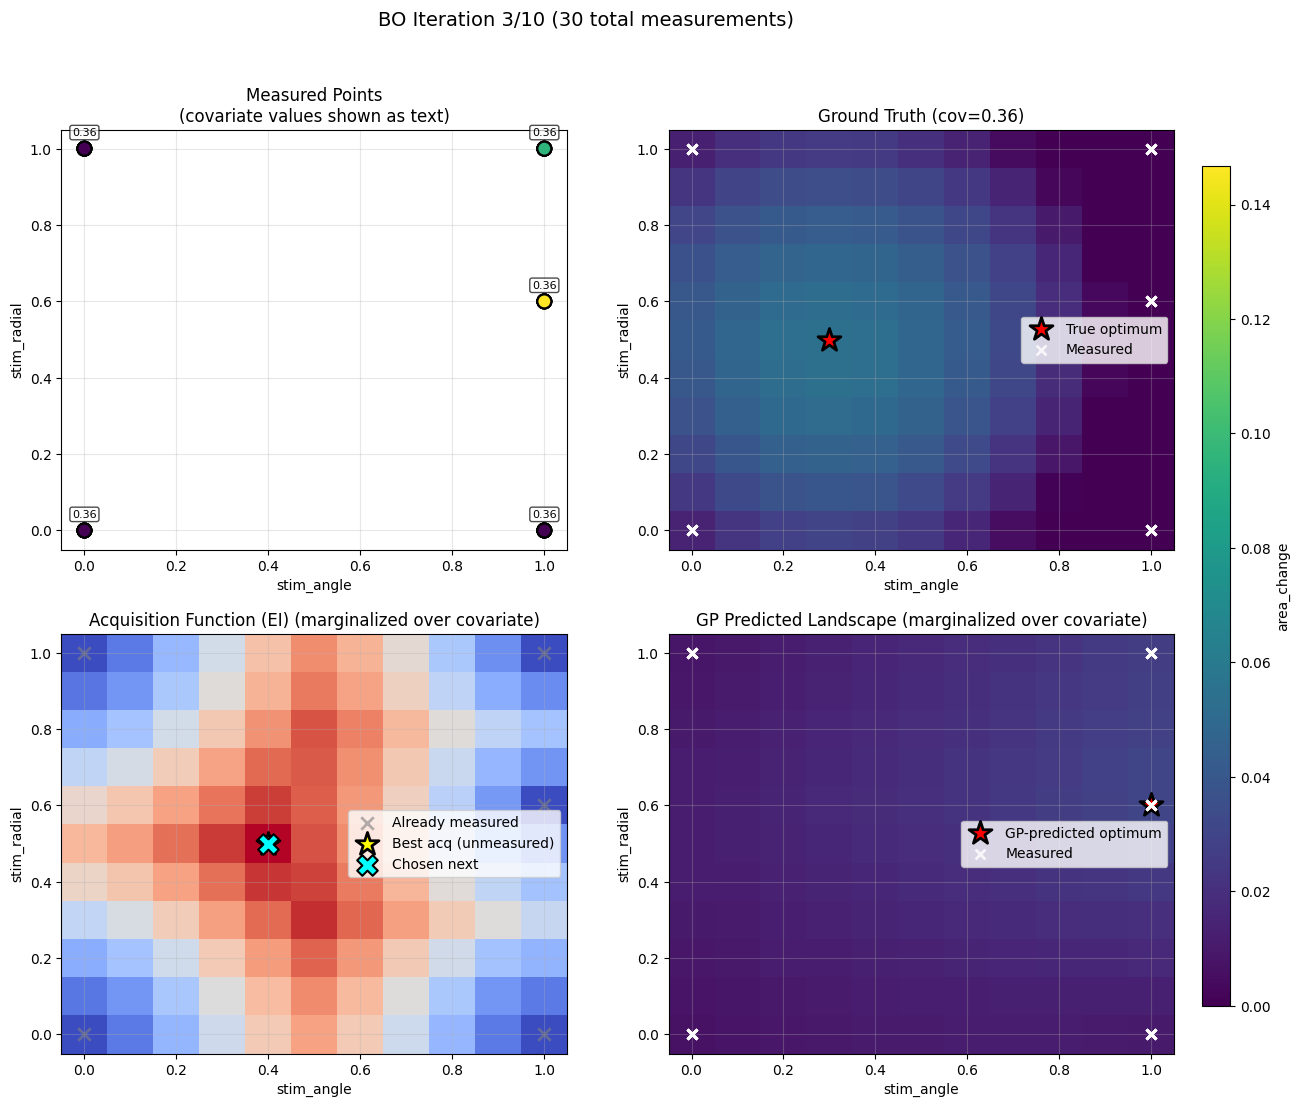

Selected parameters for next experiment: {'stim_angle': np.float64(0.4), 'stim_radial': np.float64(0.5)}
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 5: 6 cells, mean area_change=0.0101

=== BO Iteration 4/10 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 398.72it/s, 7 steps of size 5.32e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.07      0.84      0.87      0.07      2.03    631.57      1.00
k_length[1]      1.16      0.86      0.98      0.20      2.07    543.41      1.00
k_length[2]      0.51      0.87      0.37      0.08      0.76    244.53      1.00
    k_scale      0.62      0.28      0.57      0.21      1.03   1259.13      1.00
      noise      0.47      0.20      0.43      0.17      0.75    409.70      1.00

Computing robust acquisition over 1150 scenarios (115 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=-0.255945, max=1.795995
  Robust acq stats: min=0.002566, max=0.024295
Computing robust acquisition over 60 scenarios (6 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=-0.340073, max=1.798856
  Robust acq stats: min=0.000000, max=0.000000


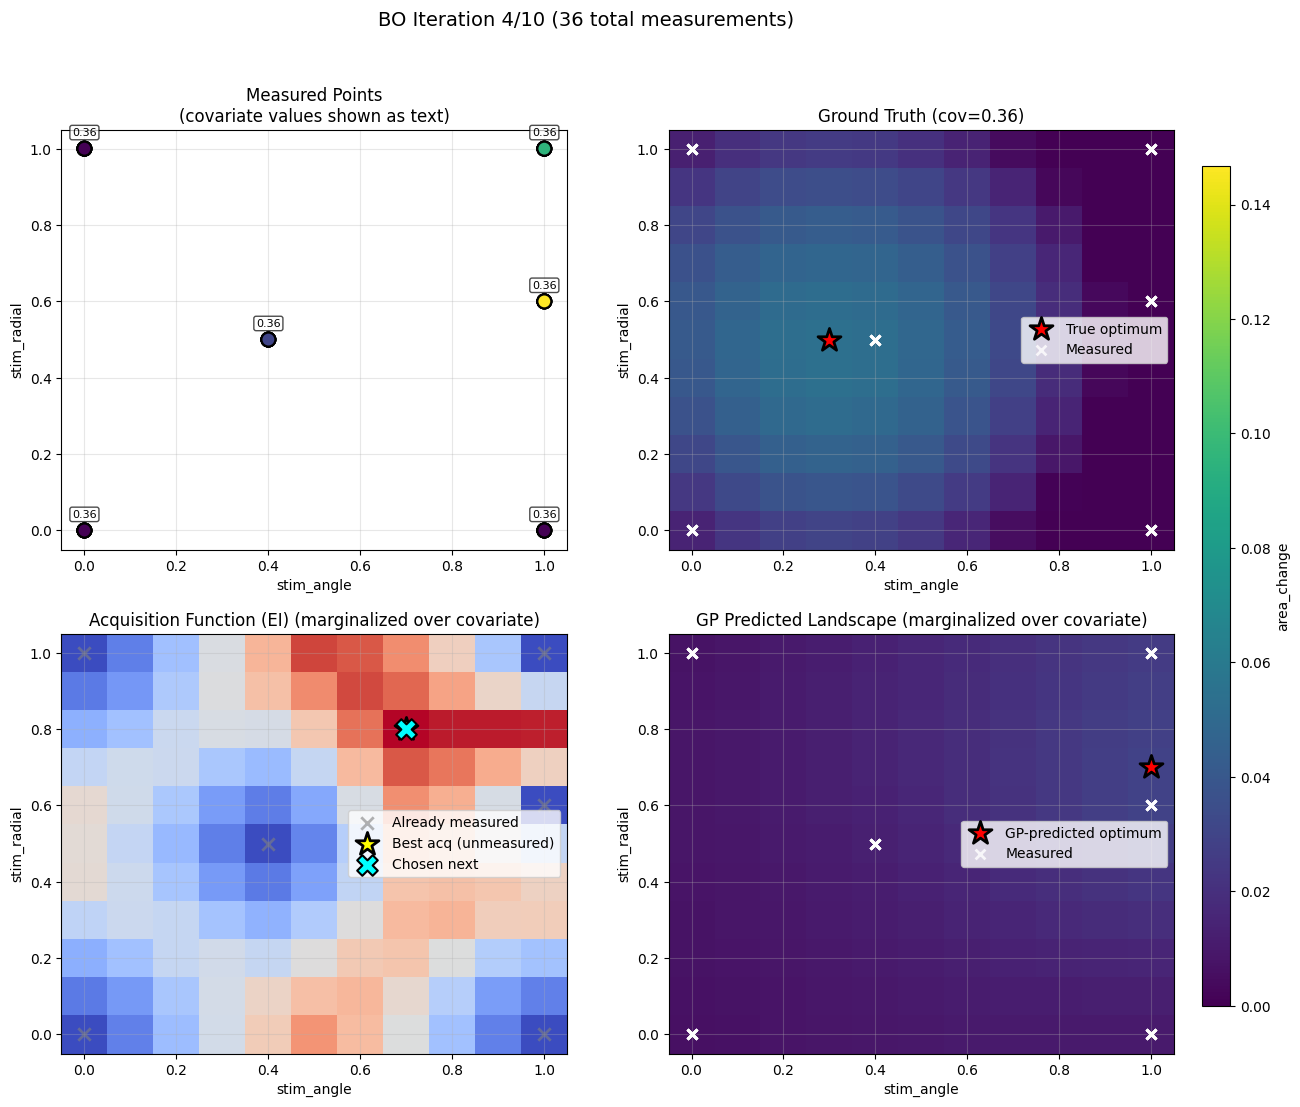

Selected parameters for next experiment: {'stim_angle': np.float64(0.7000000000000001), 'stim_radial': np.float64(0.8)}
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 6: 6 cells, mean area_change=0.0645

=== BO Iteration 5/10 ===


sample: 100%|██████████| 1200/1200 [00:02<00:00, 424.26it/s, 7 steps of size 5.80e-01. acc. prob=0.82]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.07      1.16      0.73      0.08      2.23    615.55      1.00
k_length[1]      1.12      1.10      0.83      0.08      2.10    789.23      1.00
k_length[2]      1.48      2.43      0.58      0.06      3.69    475.24      1.00
    k_scale      0.55      0.29      0.49      0.12      0.93    982.55      1.00
      noise      0.62      0.21      0.59      0.27      0.93    407.30      1.00

Computing robust acquisition over 1140 scenarios (114 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.177760, max=1.143553
  Robust acq stats: min=0.000414, max=0.023024
Computing robust acquisition over 70 scenarios (7 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.219058, max=1.121895
  Robust acq stats: min=0.000000, max=0.000000


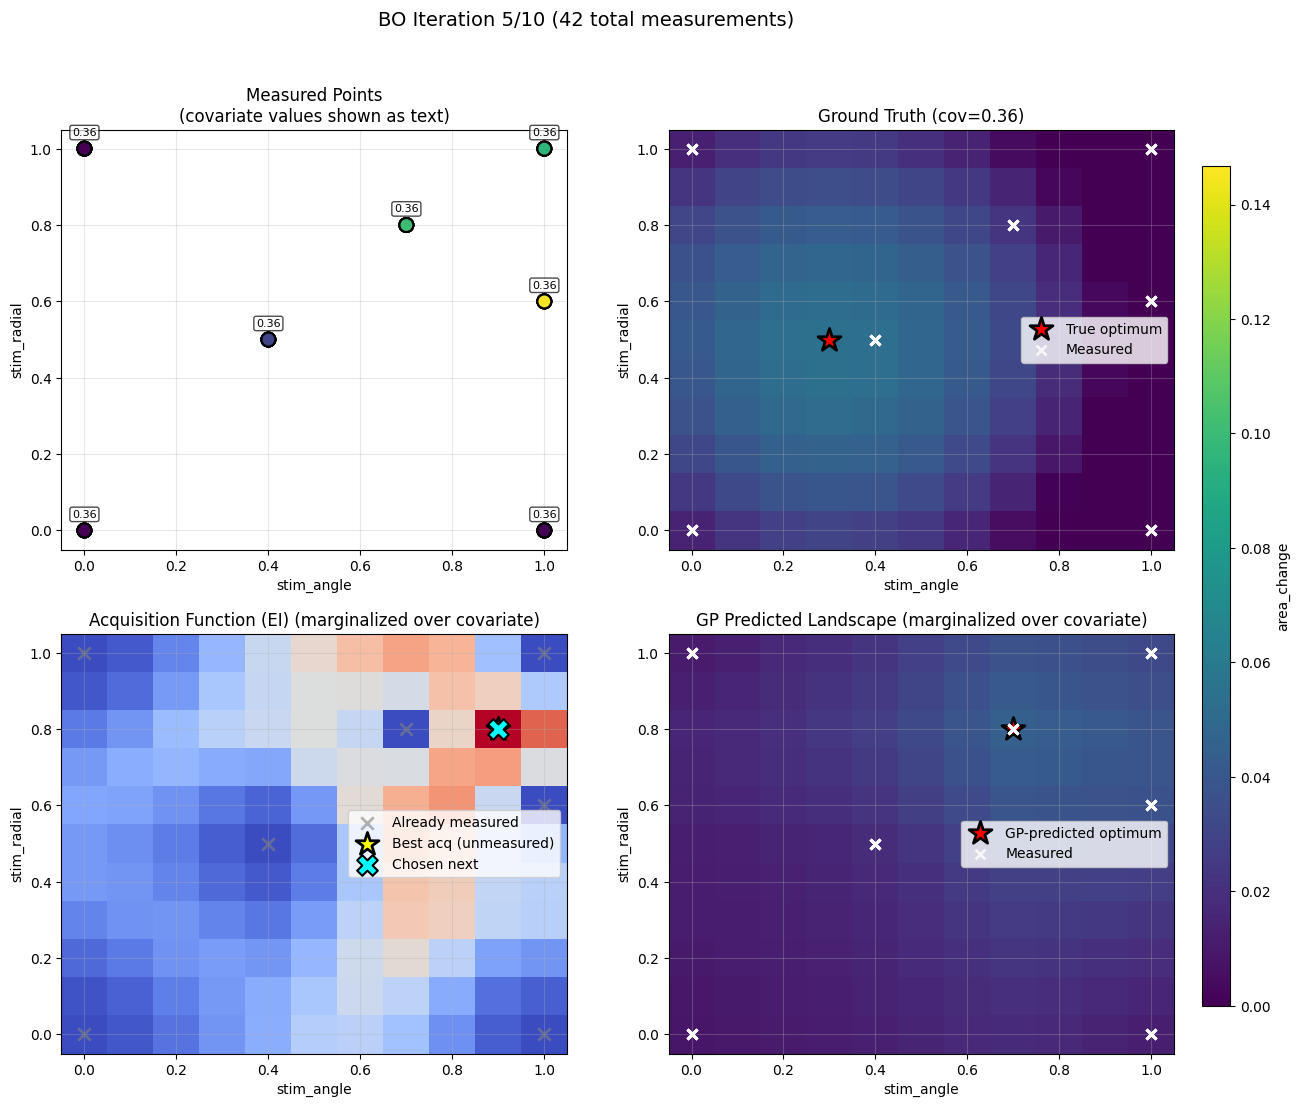

Selected parameters for next experiment: {'stim_angle': np.float64(0.9), 'stim_radial': np.float64(0.8)}
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 7: 6 cells, mean area_change=0.0814

=== BO Iteration 6/10 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 396.75it/s, 3 steps of size 6.29e-01. acc. prob=0.86]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.86      1.97      1.19      0.02      4.18    554.31      1.00
k_length[1]      0.88      1.54      0.42      0.04      1.89    449.19      1.00
k_length[2]      2.86      3.63      1.73      0.06      7.28    531.40      1.00
    k_scale      0.54      0.32      0.47      0.09      0.95    833.19      1.00
      noise      0.66      0.21      0.66      0.28      0.96    257.09      1.00

Computing robust acquisition over 1130 scenarios (113 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.533753, max=0.939828
  Robust acq stats: min=0.000025, max=0.011550
Computing robust acquisition over 80 scenarios (8 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.539164, max=1.015344
  Robust acq stats: min=0.000000, max=0.000000


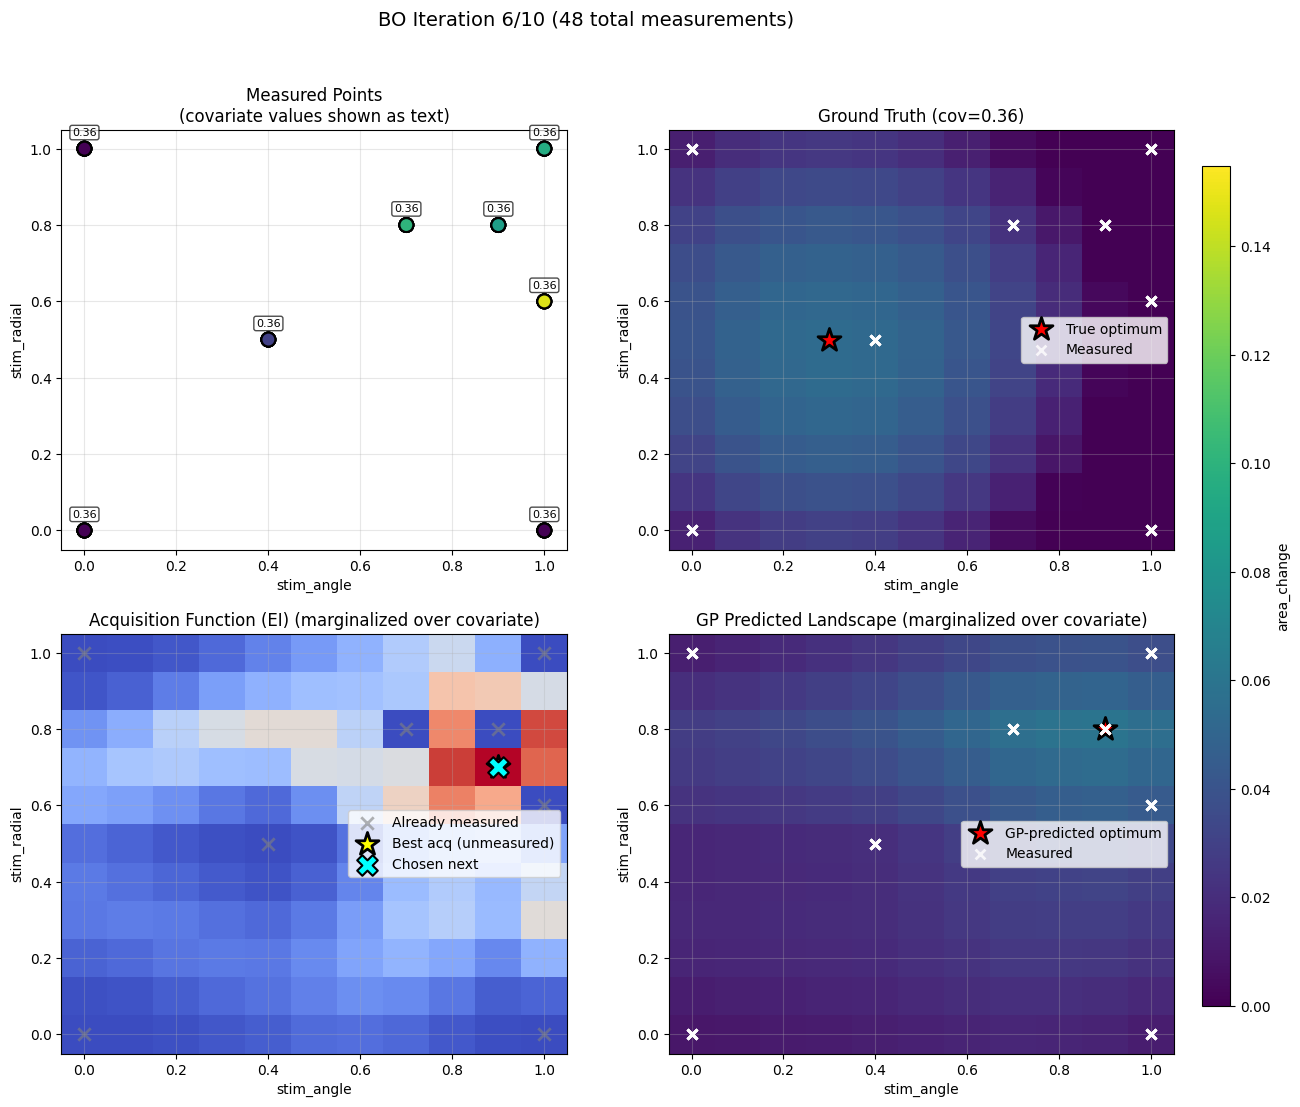

Selected parameters for next experiment: {'stim_angle': np.float64(0.9), 'stim_radial': np.float64(0.7000000000000001)}
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 8: 6 cells, mean area_change=0.0424

=== BO Iteration 7/10 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 353.93it/s, 11 steps of size 5.90e-01. acc. prob=0.80]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      2.10      2.34      1.44      0.03      4.47    562.92      1.00
k_length[1]      0.65      0.87      0.33      0.06      1.47    345.65      1.00
k_length[2]      1.95      2.88      0.59      0.04      5.54    290.21      1.00
    k_scale      0.56      0.30      0.51      0.10      0.90    608.15      1.00
      noise      0.59      0.21      0.59      0.25      0.90    137.09      1.00

Computing robust acquisition over 1120 scenarios (112 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.769754, max=0.784106
  Robust acq stats: min=0.000000, max=0.013750
Computing robust acquisition over 90 scenarios (9 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.794771, max=0.828883
  Robust acq stats: min=0.000000, max=0.000000


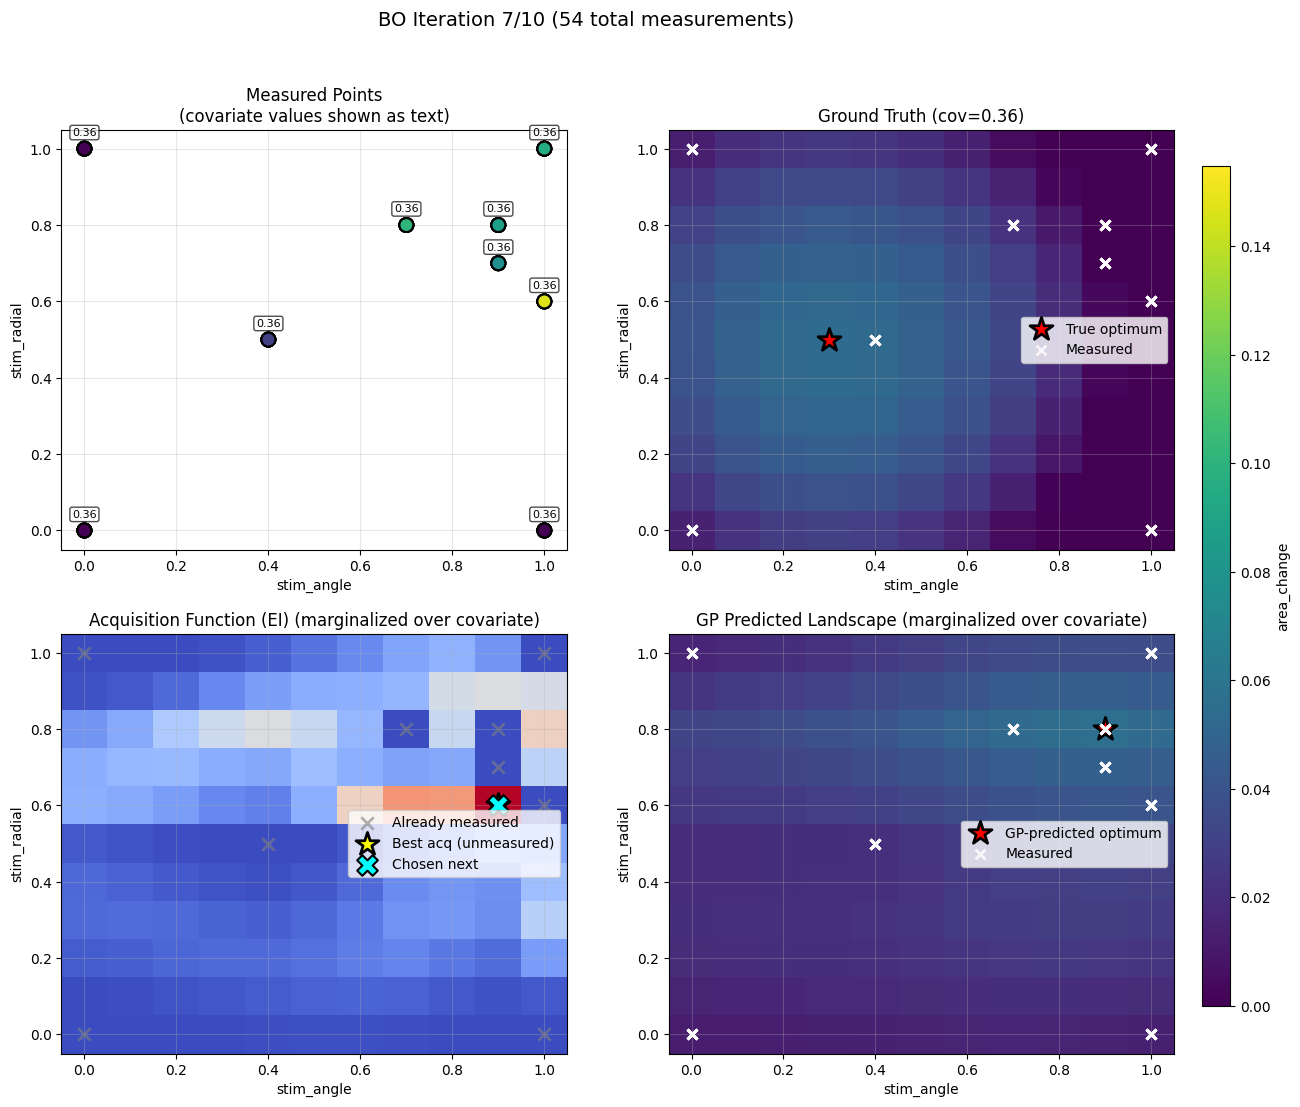

Selected parameters for next experiment: {'stim_angle': np.float64(0.9), 'stim_radial': np.float64(0.6000000000000001)}
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 9: 6 cells, mean area_change=0.0716

=== BO Iteration 8/10 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 348.63it/s, 7 steps of size 4.72e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.29      1.72      0.79      0.05      2.80    797.77      1.00
k_length[1]      1.28      1.42      0.89      0.03      2.69    656.51      1.00
k_length[2]      4.33      4.29      3.29      0.06      8.80    983.77      1.00
    k_scale      0.50      0.31      0.43      0.12      0.92    825.21      1.00
      noise      0.72      0.15      0.70      0.49      0.96    711.81      1.00

Computing robust acquisition over 1110 scenarios (111 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.453880, max=0.681821
  Robust acq stats: min=0.000026, max=0.008113
Computing robust acquisition over 100 scenarios (10 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.433384, max=0.706205
  Robust acq stats: min=0.000000, max=0.000000


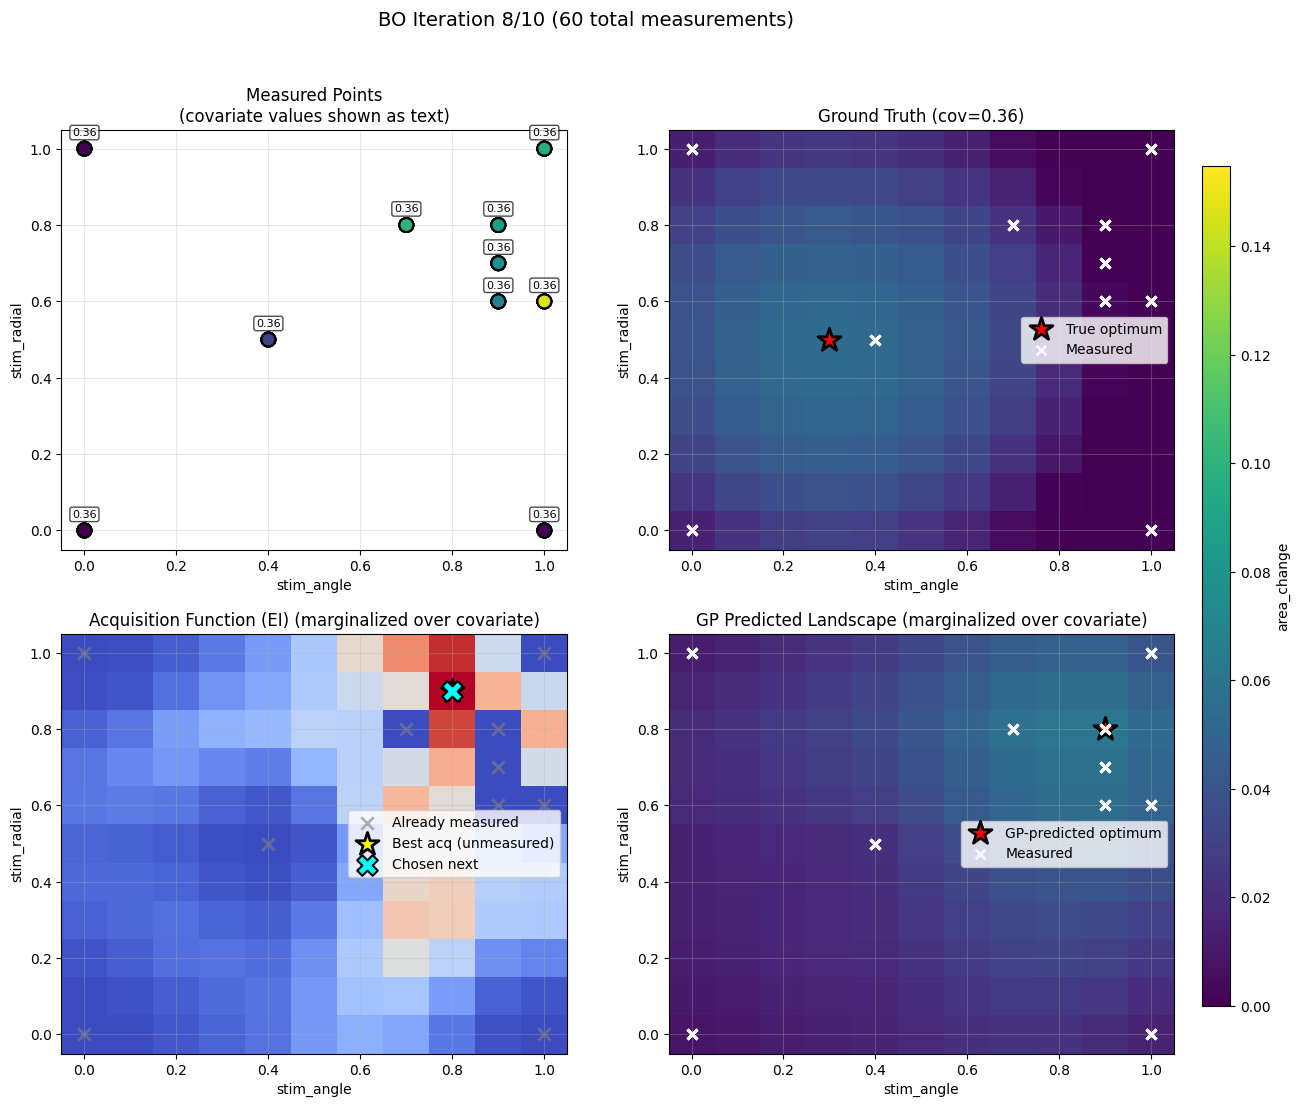

Selected parameters for next experiment: {'stim_angle': np.float64(0.8), 'stim_radial': np.float64(0.9)}
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 10: 6 cells, mean area_change=0.0802

=== BO Iteration 9/10 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 325.82it/s, 7 steps of size 5.55e-01. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.03      1.20      0.70      0.05      2.04    461.29      1.00
k_length[1]      1.52      1.57      1.14      0.03      3.08    423.97      1.00
k_length[2]      5.12      4.69      3.80      0.08     10.09    902.55      1.00
    k_scale      0.59      0.37      0.50      0.15      1.04    740.78      1.00
      noise      0.69      0.14      0.68      0.50      0.94    615.01      1.00

Computing robust acquisition over 1100 scenarios (110 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.481783, max=0.756292
  Robust acq stats: min=0.000002, max=0.005522
Computing robust acquisition over 110 scenarios (11 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.452889, max=0.742959
  Robust acq stats: min=0.000000, max=0.000000


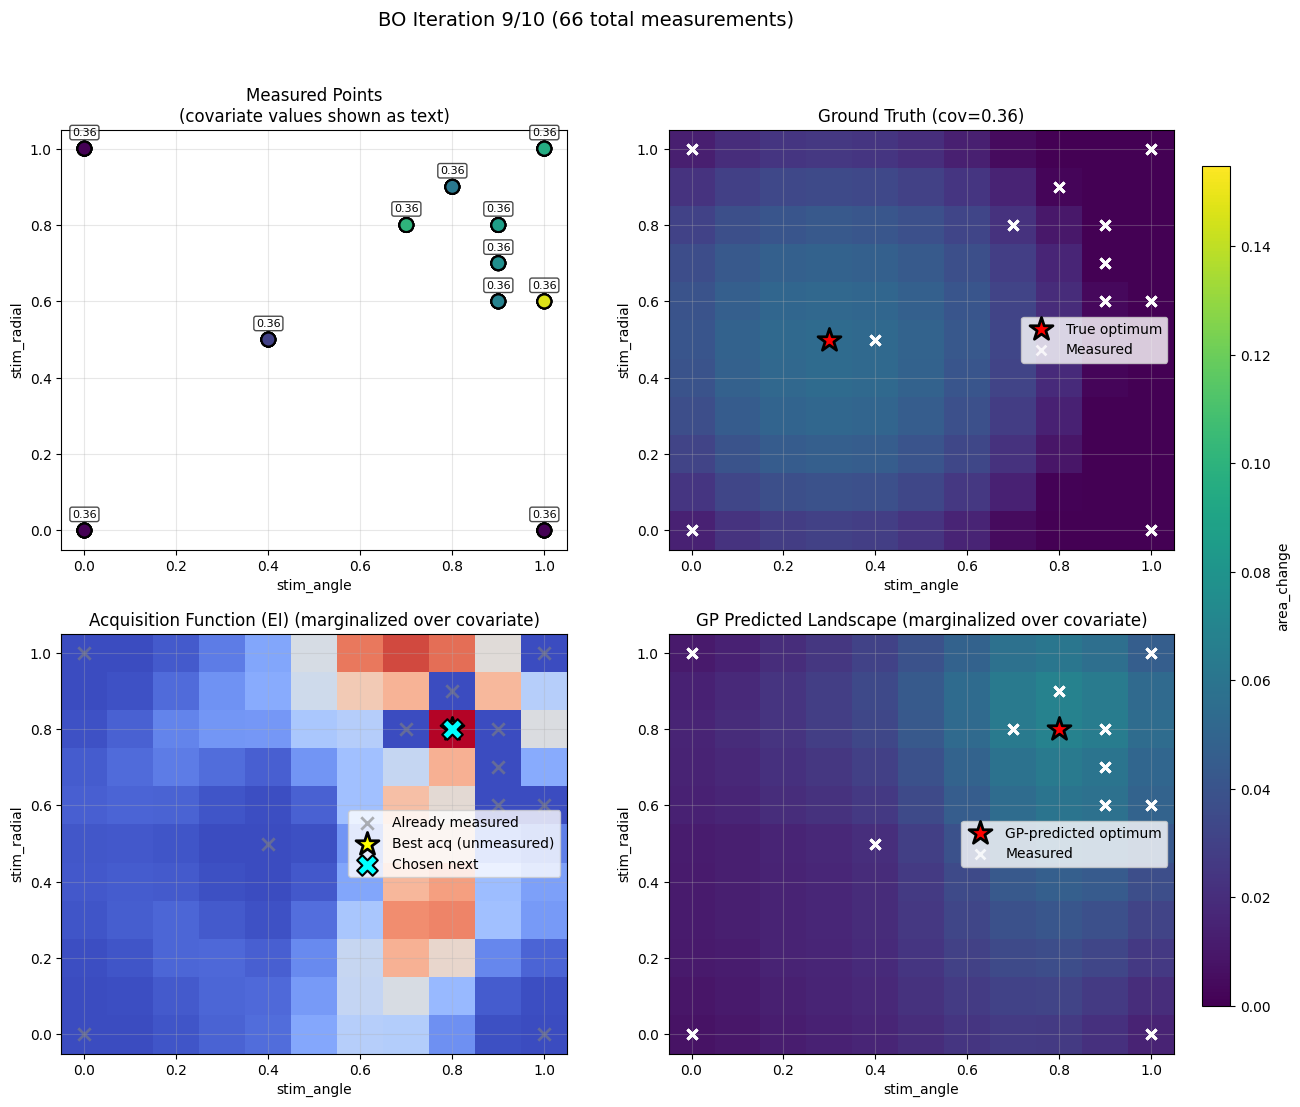

Selected parameters for next experiment: {'stim_angle': np.float64(0.8), 'stim_radial': np.float64(0.8)}
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 11: 6 cells, mean area_change=0.1412

=== BO Iteration 10/10 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 316.56it/s, 5 steps of size 6.82e-01. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.66      1.12      0.32      0.03      1.46    256.54      1.00
k_length[1]      1.90      2.44      1.09      0.04      4.41    505.38      1.00
k_length[2]      6.49      4.68      5.38      0.18     12.22    761.92      1.00
    k_scale      0.62      0.36      0.54      0.19      1.14    968.42      1.00
      noise      0.60      0.11      0.58      0.42      0.77    747.81      1.00

Computing robust acquisition over 1090 scenarios (109 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.660193, max=0.811488
  Robust acq stats: min=0.000001, max=0.011534
Computing robust acquisition over 120 scenarios (12 grid points x 10 covariate samples)...
  best_f per covariate (scaled): min=0.826094, max=1.015972
  Robust acq stats: min=0.000000, max=0.000000


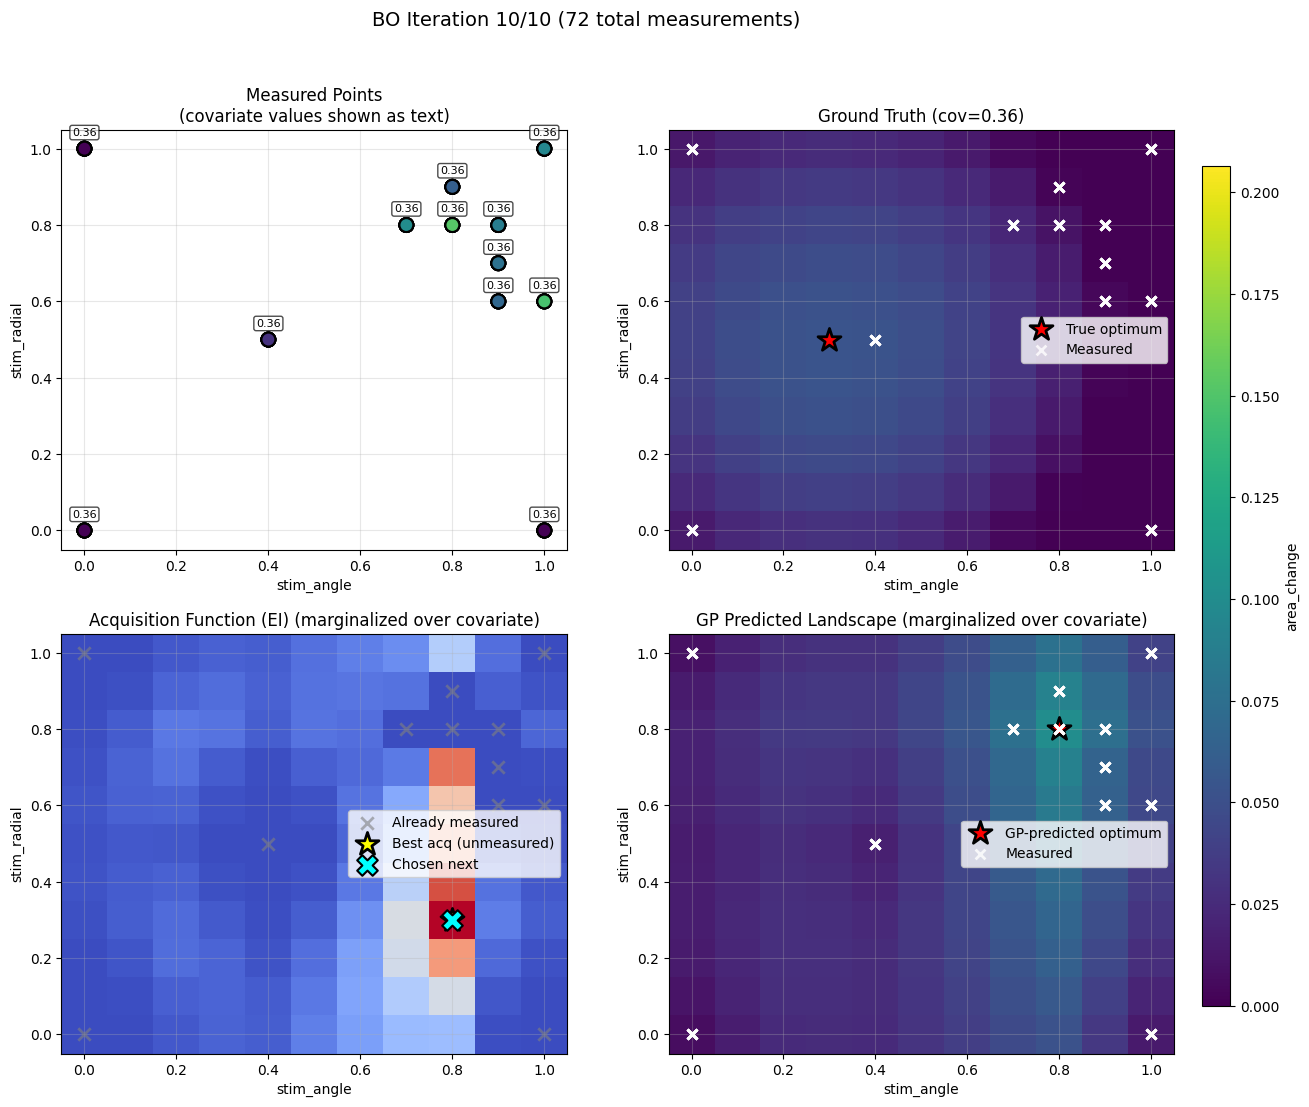

Selected parameters for next experiment: {'stim_angle': np.float64(0.8), 'stim_radial': np.float64(0.30000000000000004)}
Total Experiment Time: 0.006111111111111111h
Doing 1 experiment per stim condition
  Phase 12: 6 cells, mean area_change=0.1704


,label,x,y,area,fov,fov_x,fov_y,fov_name,timestep,time,...,stim_channel_device_name,stim_channel_power_property_name,stim_exposure,stim,stim_angle,stim_radial,optocheck,time_acquired,fov_timestep,particle
0,1,56.973266,296.993497,1384.0,0,494.0,494.0,centre,0,0.0,...,Spectra,Cyan_Level,0.0,False,0.0,1.0,False,2026-02-26-11:37:00,0,0
1,2,120.987265,132.996124,1806.0,0,494.0,494.0,centre,0,0.0,...,Spectra,Cyan_Level,0.0,False,0.0,1.0,False,2026-02-26-11:37:00,0,1
2,3,191.987265,480.996124,1806.0,0,494.0,494.0,centre,0,0.0,...,Spectra,Cyan_Level,0.0,False,0.0,1.0,False,2026-02-26-11:37:00,0,2
3,4,350.973266,144.993497,1384.0,0,494.0,494.0,centre,0,0.0,...,Spectra,Cyan_Level,0.0,False,0.0,1.0,False,2026-02-26-11:37:00,0,3
4,5,426.973266,157.993497,1384.0,0,494.0,494.0,centre,0,0.0,...,Spectra,Cyan_Level,0.0,False,0.0,1.0,False,2026-02-26-11:37:00,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
931,2,121.000000,133.000000,2463.0,0,494.0,494.0,centre,11,22.0,...,Spectra,Cyan_Level,100.0,True,0.8,0.3,False,2026-02-26-11:45:45,155,1
932,3,192.000000,481.000000,2133.0,0,494.0,494.0,centre,11,22.0,...,Spectra,Cyan_Level,100.0,True,0.8,0.3,False,2026-02-26-11:45:45,155,2
933,4,350.987265,144.996124,1806.0,0,494.0,494.0,centre,11,22.0,...,Spectra,Cyan_Level,100.0,True,0.8,0.3,False,2026-02-26-11:45:45,155,3
934,5,426.987265,157.996124,1806.0,0,494.0,494.0,centre,11,22.0,...,Spectra,Cyan_Level,100.0,True,0.8,0.3,False,2026-02-26-11:45:45,155,4


In [ ]:
bo_params = [
    BO_Parameter(name="stim_angle", bounds=(0.0, 1.0), param_type="float", spacing=0.1),
    BO_Parameter(
        name="stim_radial", bounds=(0.0, 1.0), param_type="float", spacing=0.1
    ),
]
bo_covariates = [
    BO_Covariate(name="opto_rtk_expression"),
]
bo_objective = BO_Objective(name="area_change", goal="maximize")


bo_agent = ProtrusionBOptGPAX(
    microscope=mic,
    storage_path=path,
    channels=channels,
    condition=condition,
    stim_treatment=stim_treatment,
    n_frames=N_FRAMES,
    first_frame_stim=FIRST_FRAME_STIMULATION,
    time_between_timesteps=TIME_BETWEEN_TIMESTEPS,
    time_per_fov=TIME_PER_FOV,
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=10,
    acquisition_function="ei",
    ei_xi=0.1,
    penalty="inverse_distance",
    penalty_factor=2.0,
    verbose=True,
)

bo_agent.run()

# Finalise the experiment
mic.post_experiment()

## Visualise results

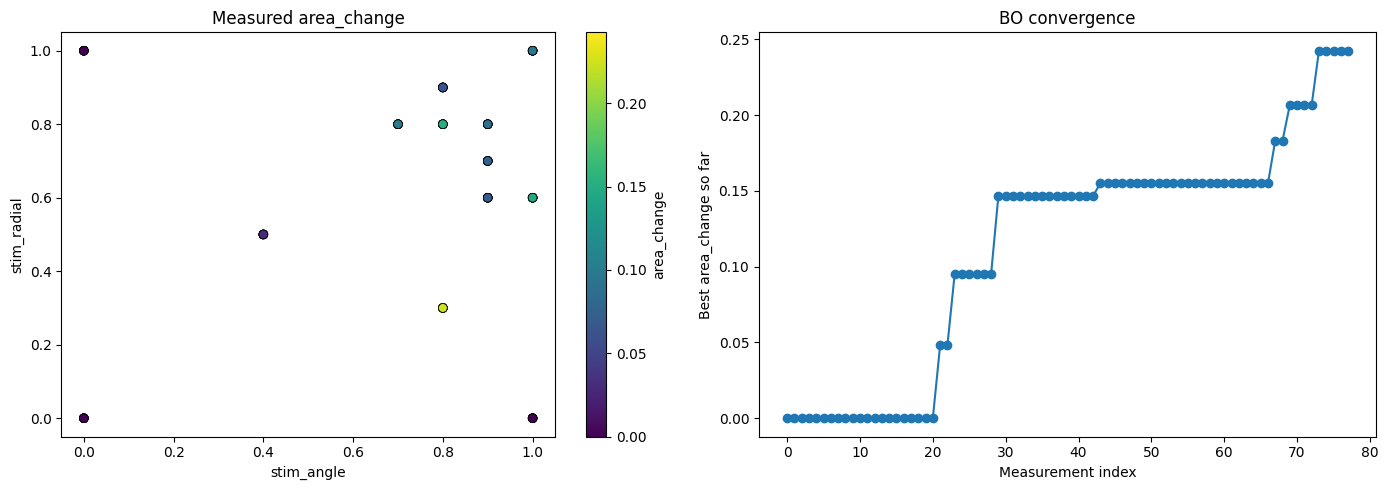

In [ ]:
# Collect all measured data from the BO agent's internal state
if bo_agent.x is not None and bo_agent.y is not None:
    x_data = np.array(bo_agent.x)
    y_data = np.array(bo_agent.y).ravel()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: scatter of (stim_angle, stim_radial) coloured by area_change
    sc = axes[0].scatter(
        x_data[:, 0],
        x_data[:, 1],
        c=y_data,
        cmap="viridis",
        s=40,
        edgecolors="k",
        linewidths=0.5,
    )
    axes[0].set_xlabel("stim_angle")
    axes[0].set_ylabel("stim_radial")
    axes[0].set_title("Measured area_change")
    fig.colorbar(sc, ax=axes[0], label="area_change")

    # Right: convergence – best objective seen so far vs iteration
    cumulative_best = np.maximum.accumulate(y_data)
    axes[1].plot(cumulative_best, "o-")
    axes[1].set_xlabel("Measurement index")
    axes[1].set_ylabel("Best area_change so far")
    axes[1].set_title("BO convergence")

    plt.tight_layout()
    plt.show()
else:
    print("No data collected yet.")

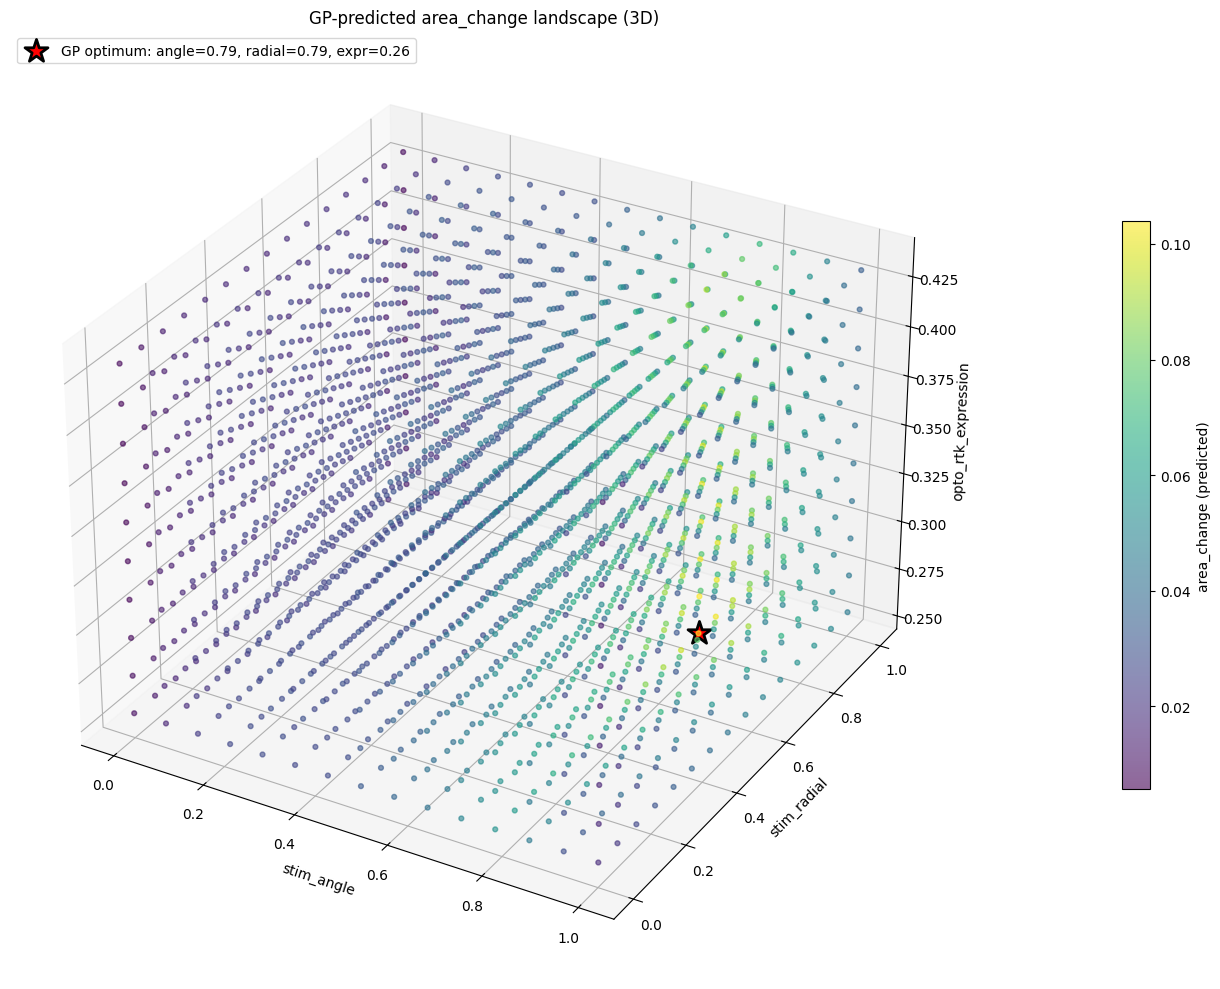


GP-predicted optimum at:
  stim_angle = 0.786
  stim_radial = 0.786
  opto_rtk_expression = 0.256
  predicted area_change = 0.1040


In [ ]:
# 3D visualization of the GP-learned landscape
# Uses the GP model from the last BO iteration to predict area_change
# over a dense grid of (stim_angle, stim_radial, opto_rtk_expression)
from mpl_toolkits.mplot3d import Axes3D
import gpax

rng_key, rng_key_pred = gpax.utils.get_keys()

# Build a dense 3D grid
angle_vals = np.linspace(0.0, 1.0, 15)
radial_vals = np.linspace(0.0, 1.0, 15)
# Use observed opto_rtk_expression range
expr_vals_obs = bo_agent.df_results["opto_rtk_expression"].values
expr_vals = np.linspace(expr_vals_obs.min(), expr_vals_obs.max(), 10)

grid_points = np.array(
    [[a, r, e] for a in angle_vals for r in radial_vals for e in expr_vals]
)

# Predict using the stored GP model + scalers
grid_scaled = bo_agent._x_scaler.transform(grid_points)
y_pred_scaled, _ = bo_agent.model.predict(rng_key_pred, grid_scaled, noiseless=True)
y_pred = bo_agent._y_scaler.inverse_transform(y_pred_scaled).flatten()

# 3D scatter: axes = the two steerable params + covariate, color = predicted area_change
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    grid_points[:, 0],
    grid_points[:, 1],
    grid_points[:, 2],
    c=np.asarray(y_pred),
    cmap="viridis",
    s=12,
    alpha=0.6,
)
ax.set_xlabel("stim_angle")
ax.set_ylabel("stim_radial")
ax.set_zlabel("opto_rtk_expression")
ax.set_title("GP-predicted area_change landscape (3D)")
cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.12)
cbar.set_label("area_change (predicted)")

# Mark the GP-predicted optimum
opt_idx = int(np.argmax(np.asarray(y_pred)))
ax.scatter(
    grid_points[opt_idx, 0],
    grid_points[opt_idx, 1],
    grid_points[opt_idx, 2],
    c="red",
    s=300,
    marker="*",
    edgecolors="black",
    linewidths=2,
    label=f"GP optimum: angle={grid_points[opt_idx,0]:.2f}, "
    f"radial={grid_points[opt_idx,1]:.2f}, "
    f"expr={grid_points[opt_idx,2]:.2f}",
    zorder=5,
)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"\nGP-predicted optimum at:")
print(f"  stim_angle = {grid_points[opt_idx, 0]:.3f}")
print(f"  stim_radial = {grid_points[opt_idx, 1]:.3f}")
print(f"  opto_rtk_expression = {grid_points[opt_idx, 2]:.3f}")
print(f"  predicted area_change = {float(y_pred[opt_idx]):.4f}")